In [ ]:
Q1: Implement a Neural Network to Solve the XOR Problem
Design and train a simple feedforward neural network from scratch to solve the XOR
classification problem.
- Input: Two binary inputs
- Output: Single binary output (0 or 1) indicating the XOR of the inputs
- Constraints:
• Do not use any deep learning or machine learning libraries
• You must implement the forward pass, backward pass (backpropagation), and weight
update manually
• Visualize the training loss
Hint:
- Use a 2-2-1 architecture (2 input neurons, 2 hidden neurons, 1 output neuron)
- Use sigmoid activation function
- When using sigmoid, remember its derivative:
sigmoid'(x) = sigmoid(x) * (1 – sigmoid(x))
- Use binary cross-entropy loss
- Choose a small learning rate (e.g., 0.1). Too large will diverge; too small will be slow.
- Train for at least 10,000 iterations or until the loss plateaus.
- Initialize weights randomly and train using gradient descent

Epoch 0, Loss: 0.704922
Loss plateaued at epoch 52, stopping early.

Final predictions on XOR inputs:
Input: [0 0] → Predicted: 1, Actual: 0
Input: [0 1] → Predicted: 0, Actual: 1
Input: [1 0] → Predicted: 1, Actual: 1
Input: [1 1] → Predicted: 0, Actual: 0


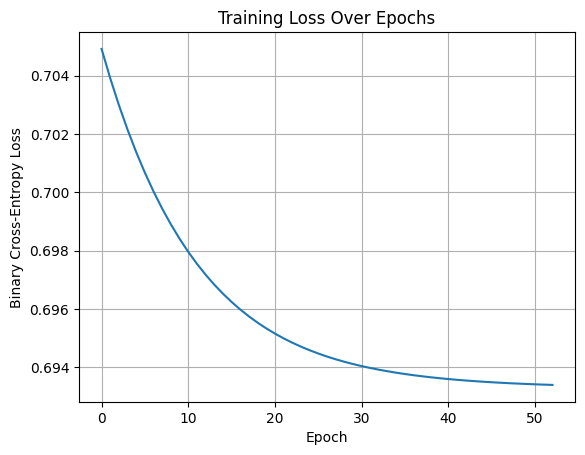

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sigmoid activation and its derivative ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(sig):
    return sig * (1 - sig)

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8  # to avoid log(0)
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

# --- XOR dataset ---
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])

# --- Hyperparameters ---
input_size = 2
hidden_size = 2
output_size = 1
learning_rate = 0.1
epochs = 10000
tolerance = 1e-5  


np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

losses = []
last_loss = float('inf')

for epoch in range(epochs):
    
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    loss = binary_cross_entropy(y, a2)
    losses.append(loss)

    
    if abs(last_loss - loss) < tolerance:
        print(f"Loss plateaued at epoch {epoch}, stopping early.")
        break
    last_loss = loss

  
    d_loss_output = a2 - y  
    d_output_z2 = sigmoid_derivative(a2)
    d_z2 = d_loss_output * d_output_z2

    dW2 = np.dot(a1.T, d_z2)
    db2 = np.sum(d_z2, axis=0, keepdims=True)

    d_hidden = np.dot(d_z2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, d_hidden)
    db1 = np.sum(d_hidden, axis=0, keepdims=True)

  
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

predictions = (a2 > 0.5).astype(int)
print("\nFinal predictions on XOR inputs:")
for i in range(4):
    print(f"Input: {X[i]} → Predicted: {predictions[i][0]}, Actual: {y[i][0]}")

# --- Plot training loss ---
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()


Epoch 0, Loss: 0.6144, Accuracy: 0.67
Epoch 1000, Loss: 0.0518, Accuracy: 1.00
Epoch 2000, Loss: 0.0321, Accuracy: 1.00
Epoch 3000, Loss: 0.0249, Accuracy: 1.00
Epoch 4000, Loss: 0.0210, Accuracy: 1.00
Epoch 5000, Loss: 0.0184, Accuracy: 1.00
Epoch 6000, Loss: 0.0166, Accuracy: 1.00
Epoch 7000, Loss: 0.0152, Accuracy: 1.00
Epoch 8000, Loss: 0.0141, Accuracy: 1.00
Epoch 9000, Loss: 0.0132, Accuracy: 1.00

Final Predictions:
[1 0 1 0 1 0]


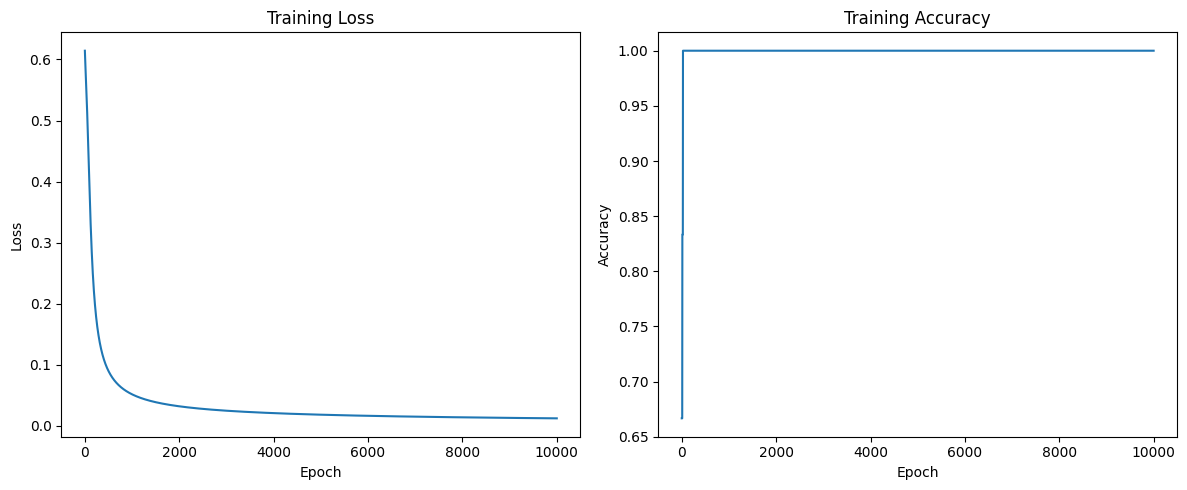

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))


X = np.array([
    [0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 0],
    [1, 1, 0, 0, 1, 1],
    [0, 0, 1, 1, 0, 0],
    [1, 1, 1, 0, 0, 1],
    [0, 0, 0, 1, 1, 0]
])
y = np.array([[1], [0], [1], [0], [1], [0]])

# --- Parameters ---
input_size = 6
hidden_size = 3
output_size = 1
learning_rate = 0.1
epochs = 10000


np.random.seed(1)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

losses = []
accuracies = []

for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

  
    loss = binary_cross_entropy(y, a2)
    losses.append(loss)
    predictions = (a2 > 0.5).astype(int)
    accuracy = np.mean(predictions == y)
    accuracies.append(accuracy)

  
    d_loss = a2 - y
    dW2 = np.dot(a1.T, d_loss * sigmoid_derivative(a2))
    db2 = np.sum(d_loss * sigmoid_derivative(a2), axis=0, keepdims=True)

    d_hidden = np.dot(d_loss * sigmoid_derivative(a2), W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, d_hidden)
    db1 = np.sum(d_hidden, axis=0, keepdims=True)

    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.2f}")

print("\nFinal Predictions:")
print(predictions.flatten())

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()
